# TCCT S94 - Mixed-Context Robustness Blind Test

The frozen S92B pair decoder is evaluated without retraining on a new 13-branch grammar. Non-query branches alternate Continue and Stop in two phases, while the queried branch alone changes between each matched pair. New depths and three-layer topology compositions are used. Both pair orientations are scored.

Run **Kernel -> Restart Kernel and Run All Cells**. Expected runtime is about 10-15 minutes. Preserve the first certificate regardless of outcome.


Dataset[{<|Stage -> S86, Name -> ExternalSixBranchBlind, CandidateFileLoaded -> True, 
 
>     CandidateHash -> a51e6a13bdeda37b041eee4b74cfb6e472c7e52107a60f1d5534bb5df44ce44f, 
 
>     ExpectedCandidateHash -> 
 
>      a51e6a13bdeda37b041eee4b74cfb6e472c7e52107a60f1d5534bb5df44ce44f, 
 
>     CandidateK -> 19, CandidatePolicyLength -> 26, 
 
>     OriginalFrozenModelChanged -> False, FrozenCandidateChanged -> False, 
 
>     CoreChanged -> False, PreflightPassed -> True|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Stage, Name, CandidateFileLoaded, 
 
>      CandidateHash, ExpectedCandidateHash, CandidateK, CandidatePolicyLength, 
 
>      OriginalFrozenModelChanged, FrozenCandidateChanged, CoreChanged, PreflightPassed}\
 
>      , {TypeSystem`Atom[String], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[String], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean]}], 1], 
 
>   <||>]
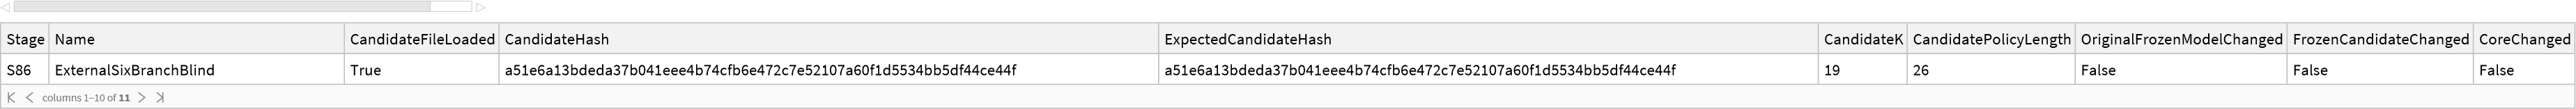

In [1007]:
ClearAll["Global`*"];
$HistoryLength=0;

expectedFrozenModelHash79A=
"d6477c370436d09cf3e8cfc8530decd13ebf8bb79120362146ecb419f9d6a6c4";
expectedTopologySpecHash79A=
"b108aa7f2c59c395056fb9124e7d5d9074e39e5e124d0d98011800433e0dd95b";
expectedTopologyImplementationHash79A=
"f27d1ce683317d35a5e9da01536d95c706065810c27462e336cdb76f4a2dab52";
expectedS79BlindResultHash79A=
"b1ebf089e43121a61d4181139d4ba0a8970dc646a7a41425f861cff2e1f8661d";

frozen75D=<|
"Stage"->"S75D",
"Name"->"ValidatedPolicyCompletion",
"Representation"->
"PairedRadius2Radius3WithParentChildCardinality",
"Params"->{-1,0,-1,-1,-1,0,1,-1},
"K"->5,
"TrainingPolicy"->{{3,1},{3,3},{4,3}},
"Policy"->{
{1,3},{2,2},{3,1},{3,2},{3,3},{4,3}
},
"AddedContinueCodes"->{{1,3},{2,2},{3,2}},
"PolicyCompletionUsesValidationLabels"->True,
"FrozenBeforeS76"->True
|>;

P59[a_,b_,n_Integer,s_Integer]:=If[
n<=0,
{DirectedEdge[a,b]},
DirectedEdge@@@Partition[
Join[{a},Range[s,s+n-1],{b}],
2,
1
]
];

A59[t_,fan_Integer,s_Integer]:=Module[{p1,p2,ls},
p1=s+1;
p2=s+2;
ls=Range[s+3,s+2+fan];
Join[
{
DirectedEdge[p2,p1],
DirectedEdge[p1,t]
},
Table[
DirectedEdge[ls[[i]],p2],
{i,Length[ls]}
]
]
];

T59[d_Integer,r_String,a_Integer,seed_Integer]:=Module[
{
bb,K,c,v,q,e,f={},ib,m,safe,u,dum,r1,r2,wrong,
main,perm,anc,i
},
bb=1000000000 seed;
K=bb+1;
c=Table[bb+100+i,{i,4}];
v=Table[bb+200+i,{i,4}];
q=Table[bb+300+i,{i,4}];
e=Flatten[
Table[
{
DirectedEdge[K,c[[i]]],
DirectedEdge[c[[i]],v[[i]]]
},
{i,4}
],
1
];
Do[
ib=bb+20000000 i;
m=ib+1;
safe=ib+2;
u=ib+3;
dum=ib+4;
r1=ib+10;
r2=ib+20;
wrong=c[[1+Mod[i,4]]];
main=Join[
P59[q[[i]],r1,d,ib+1000000],
P59[q[[i]],r2,d,ib+2000000],
{
DirectedEdge[r1,m],
DirectedEdge[r2,m]
},
P59[q[[i]],safe,d+1,ib+3000000]
];
perm=If[
r==="Continue",
{
DirectedEdge[m,c[[i]]],
DirectedEdge[safe,dum],
DirectedEdge[u,wrong]
},
{
DirectedEdge[m,wrong],
DirectedEdge[safe,c[[i]]],
DirectedEdge[u,dum]
}
];
anc=Join[
A59[m,i,bb+970000000+10000 i],
A59[c[[i]],i,bb+980000000+10000 i]
];
e=Join[e,main,perm,anc];
AppendTo[f,m],
{i,4}
];
{{Union[e],q,K,v,c,f},a}
];

Case59[d_Integer,a_Integer,r_String]:=
T59[d,r,a,59000000+100 d+a];

rw60={-9,6,-2,-2,4,2,-2,6,0};

Pack60[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,v,pos,gi,go,pa,ch,id,od,
pin,pout,cin,cout},
e=x[[1]];
v=Union@Join[
Flatten[List@@@e],
x[[2]],
{x[[3]]},
x[[4]],
x[[5]],
x[[6]]
];
pos=AssociationThread[v,Range[Length[v]]];
gi=GroupBy[
Cases[e,DirectedEdge[u_,w_]:>{w,u}],
First->Last
];
go=GroupBy[
Cases[e,DirectedEdge[u_,w_]:>{u,w}],
First->Last
];
pa=(Lookup[pos,Lookup[gi,#,{}]]&)/@v;
ch=(Lookup[pos,Lookup[go,#,{}]]&)/@v;
id=Length/@pa;
od=Length/@ch;
pin=(Total[id[[#]]]&)/@pa;
pout=(Total[od[[#]]]&)/@pa;
cin=(Total[id[[#]]]&)/@ch;
cout=(Total[od[[#]]]&)/@ch;
{
pa,id,od,
Lookup[pos,x[[2,a]]],
Lookup[pos,x[[5]]],
a,
Length[v],
pin,pout,cin,cout,v
}
];

SigLevels61[c_List,rmax_Integer]:=Module[
{p,pa,id,od,n,ch,cur,nxt,levs,j,k,u},
p=Pack60[c];
pa=p[[1]];
id=p[[2]];
od=p[[3]];
n=p[[7]];
ch=Table[{},n];
Do[
Do[
If[u>0,ch[[u]]=Append[ch[[u]],j]],
{u,pa[[j]]}
],
{j,n}
];
cur=AssociationThread[
Range[n],
MapThread[List,{id,od}]
];
levs={cur};
Do[
nxt=AssociationThread[
Range[n],
Table[
{
Lookup[cur,j],
Sort[Lookup[cur,pa[[j]]]],
Sort[Lookup[cur,ch[[j]]]]
},
{j,n}
]
];
AppendTo[levs,nxt];
cur=nxt,
{k,rmax}
];
levs
];

PropagationSafetyCap78[c_List]:=Module[{n},
n=Pack60[c][[7]];
Max[64,2 n+8]
];

RejectTrace78[c_List]:=Module[
{
p,pa,id,od,q,n,pin,pout,cin,cout,h,z,h2,nz,j,k,
aps,ap,pz,o,zv,rf,rd,dd,pg,allow,active=0,
rej={},rounds=0,terminatedNaturally=False,safetyCap
},
p=Pack60[c];
pa=p[[1]];
id=p[[2]];
od=p[[3]];
q=p[[4]];
n=p[[7]];
pin=p[[8]];
pout=p[[9]];
cin=p[[10]];
cout=p[[11]];
safetyCap=Max[64,2 n+8];
h=ConstantArray[0,n];
z=ConstantArray[0,n];
h[[q]]=1;
For[
k=1,
k<=safetyCap,
k++,
rounds=k;
h2=ConstantArray[0,n];
nz=ConstantArray[0,n];
active=0;
Do[
aps=Select[
pa[[j]],
Function[u,u>0&&h[[u]]==1]
];
ap=Length[aps];
If[
ap>0,
pz=Max[z[[aps]]];
o=Boole[ap>1];
zv={0,1,2,1,3,1,3,1}[[1+2 pz+o]];
nz[[j]]=zv;
rf={
1,
Boole[zv>0],
zv,
Sign[pin[[j]]-id[[j]]],
Sign[pout[[j]]-id[[j]]],
Sign[cin[[j]]-id[[j]]],
Sign[cout[[j]]-od[[j]]],
Sign[id[[j]]-od[[j]]],
Sign[pout[[j]]-cin[[j]]]
};
rd=rw60.rf;
dd=1-cin[[j]]+2 cout[[j]];
pg=od[[j]]+2 Boole[zv>0]-zv;
If[rd>0&&dd<=0,AppendTo[rej,{k,j}]];
allow=If[rd>0,dd>0,pg>0];
If[
TrueQ[allow],
h2[[j]]=1;
active++
]
],
{j,n}
];
h=h2;
z=nz;
If[
active==0,
terminatedNaturally=True;
Break[]
]
];
<|
"Rejects"->rej,
"RoundsExecuted"->rounds,
"TerminatedNaturally"->terminatedNaturally,
"SafetyCap"->safetyCap,
"HitSafetyCap"->And[
!TrueQ[terminatedNaturally],
SameQ[rounds,safetyCap]
],
"ActiveAfterLastRound"->active,
"PackedNodeCount"->n
|>
];

DecisionStatePairsFromRejects78[c_List,rej_List]:=Module[
{levels,nodes},
If[Length[rej]==0,Return[{}]];
levels=SigLevels61[c,3];
nodes=rej[[All,2]];
DeleteDuplicates[
Map[
Function[node,
{
Lookup[levels[[3]],node],
Lookup[levels[[4]],node]
}
],
nodes
]
]
];

EncodeRows75[data_List,p_List,k_Integer]:=Module[{rec},
rec[s_]:=rec[s]=If[
MatchQ[s,{_Integer,_Integer}],
1+Mod[s[[1]]+2 s[[2]],k],
Module[
{z,ps,cs,parentSum,childSum,parentSquare,childSquare},
z=rec[s[[1]]];
ps=rec/@s[[2]];
cs=rec/@s[[3]];
parentSum=Total[ps-1];
childSum=Total[cs-1];
parentSquare=Total[(ps-1)^2];
childSquare=Total[(cs-1)^2];
1+Mod[
p[[1]]+
p[[2]](z-1)+
p[[3]]parentSum+
p[[4]]childSum+
p[[5]]parentSquare+
p[[6]]childSquare+
p[[7]]Length[ps]+
p[[8]]Length[cs],
k
]
]
];
Map[
Function[row,
Join[
KeyTake[row,{"Grammar","Depth","Answer","Target"}],
<|
"Codes"->DeleteDuplicates[
Map[
Function[pair,{rec[pair[[1]]],rec[pair[[2]]]}],
row["StatePairs"]
]
]
|>
]
],
data
]
];

DiamondIn72[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,f,mx,next,new,m,incs,rm,
add,s1,s2,g,i,j},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[new,DirectedEdge[u_,v_]/;v===m:>{u,v}];
rm=DirectedEdge@@@incs;
add={};
Do[
s1=next;
s2=next+1;
g=next+2;
next=next+3;
add=Join[
add,
{
DirectedEdge[incs[[j,1]],s1],
DirectedEdge[incs[[j,1]],s2],
DirectedEdge[s1,g],
DirectedEdge[s2,g],
DirectedEdge[g,m]
}
],
{j,Length[incs]}
];
new=Join[Complement[new,rm],add],
{i,Length[f]}
];
{{Union[new],x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]},a}
];

DoubleDiamondIn79[c_List]:=Module[
{
x=c[[1]],a=c[[2]],e,f,mx,next,new,m,incs,removed,
added,parent,s1,s2,g1,t1,t2,g2,i,j
},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[new,DirectedEdge[u_,v_]/;v===m:>{u,v}];
removed=DirectedEdge@@@incs;
added={};
Do[
parent=incs[[j,1]];
s1=next;
s2=next+1;
g1=next+2;
t1=next+3;
t2=next+4;
g2=next+5;
next=next+6;
added=Join[
added,
{
DirectedEdge[parent,s1],
DirectedEdge[parent,s2],
DirectedEdge[s1,g1],
DirectedEdge[s2,g1],
DirectedEdge[g1,t1],
DirectedEdge[g1,t2],
DirectedEdge[t1,g2],
DirectedEdge[t2,g2],
DirectedEdge[g2,m]
}
],
{j,Length[incs]}
];
new=Join[Complement[new,removed],added],
{i,Length[f]}
];
{{Union[new],x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]},a}
];

Case79[
depth_Integer,
answer_Integer,
target_String
]:=DoubleDiamondIn79[
Case59[depth,answer,target]
];

topologySpec79=<|
"Topology"->"DoubleDiamondIn",
"TransformationScope"->
"EveryIncomingEdgeOfEachDecisionNode",
"Motif"->"TwoSerialPrivateDiamonds",
"CrossParentSharing"->False,
"DiamondsPerOriginalIncomingEdge"->2,
"ParentToDecisionPathLength"->5,
"NewNodesPerOriginalIncomingEdge"->6,
"ReplacementEdgesPerOriginalIncomingEdge"->9,
"EdgeDeltaPerOriginalIncomingEdge"->8,
"ReachabilityPreserved"->True,
"OriginalDecisionNodesPreserved"->True,
"TopologyUsedInS59ThroughS78"->False
|>;

topologySpecHash79=Hash[
Normal[topologySpec79],
"SHA256",
"HexString"
];

topologyImplementationHash79=Hash[
{DownValues[DoubleDiamondIn79],DownValues[Case79]},
"SHA256",
"HexString"
];

modelHash79A=Hash[
Normal[frozen75D],
"SHA256",
"HexString"
];

minimalKernelHash79A=Hash[
{
DownValues[P59],
DownValues[A59],
DownValues[T59],
DownValues[Case59],
OwnValues[rw60],
DownValues[Pack60],
DownValues[SigLevels61],
DownValues[PropagationSafetyCap78],
DownValues[RejectTrace78],
DownValues[DecisionStatePairsFromRejects78],
DownValues[EncodeRows75],
DownValues[DiamondIn72],
DownValues[DoubleDiamondIn79],
DownValues[Case79]
},
"SHA256",
"HexString"
];


ClearAll[
FindPrivateDiamond79B,
CanonicalizePrivateDiamonds79B,
CanonicalCase79B,
CaseByTopology79B,
DecisionIncomingEdgeCount79B,
ExpectedContractions79B
];

FindPrivateDiamond79B[e_List,protected_List]:=Module[
{
vertices,parents,children,harvest,ins,outs,s1,s2,
p1,p2,g
},
vertices=Union@Flatten[List@@@e];
parents=GroupBy[
Cases[e,DirectedEdge[u_,v_]:>{v,u}],
First->Last
];
children=GroupBy[
Cases[e,DirectedEdge[u_,v_]:>{u,v}],
First->Last
];
harvest=Reap[
Do[
If[
!MemberQ[protected,g],
ins=Sort@Lookup[parents,g,{}];
outs=Sort@Lookup[children,g,{}];
If[
Length[ins]===2&&Length[outs]===1,
{s1,s2}=ins;
p1=Sort@Lookup[parents,s1,{}];
p2=Sort@Lookup[parents,s2,{}];
If[
And[
Intersection[protected,{s1,s2,g}]==={},
Length[p1]===1,
SameQ[p1,p2],
SameQ[Sort@Lookup[children,s1,{}],{g}],
SameQ[Sort@Lookup[children,s2,{}],{g}],
DuplicateFreeQ[{First[p1],s1,s2,g,First[outs]}]
],
Sow[{First[p1],s1,s2,g,First[outs]}]
]
]
],
{g,vertices}
]
][[2]];
If[
harvest==={},
Missing["NotFound"],
First@Sort@First[harvest]
]
];

CanonicalizePrivateDiamonds79B[c_List]:=Module[
{
x=c[[1]],a=c[[2]],e,protected,candidate,
parent,s1,s2,g,target,removed,count=0,log={}
},
e=Union[x[[1]]];
protected=Union[
x[[2]],
{x[[3]]},
x[[4]],
x[[5]],
x[[6]]
];
While[
True,
candidate=FindPrivateDiamond79B[e,protected];
If[MissingQ[candidate],Break[]];
{parent,s1,s2,g,target}=candidate;
removed={s1,s2,g};
e=Union[
Select[
e,
Function[edge,
And[
!MemberQ[removed,edge[[1]]],
!MemberQ[removed,edge[[2]]]
]
]
],
{DirectedEdge[parent,target]}
];
count++;
AppendTo[log,candidate]
];
<|
"Case"->{{
e,
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
},a},
"Contractions"->count,
"ContractionLog"->log,
"ProtectedNodesPreserved"->And@@Map[
MemberQ[Union@Flatten[List@@@e],#]&,
protected
]
|>
];

CanonicalCase79B[c_List]:=
CanonicalizePrivateDiamonds79B[c]["Case"];

CaseByTopology79B[
topology_String,
depth_Integer,
answer_Integer,
target_String
]:=Switch[
topology,
"Base",
Case59[depth,answer,target],
"DiamondIn",
DiamondIn72[Case59[depth,answer,target]],
"DoubleDiamondIn",
DoubleDiamondIn79[Case59[depth,answer,target]],
_,
$Failed
];

DecisionIncomingEdgeCount79B[c_List]:=Module[
{e=c[[1,1]],f=c[[1,6]]},
Total[Count[e,DirectedEdge[_,#]]&/@f]
];

ExpectedContractions79B[
topology_String,
baseCase_List
]:=Switch[
topology,
"Base",
0,
"DiamondIn",
DecisionIncomingEdgeCount79B[baseCase],
"DoubleDiamondIn",
2 DecisionIncomingEdgeCount79B[baseCase],
_,
Missing["UnknownTopology"]
];

canonicalizerImplementationHash79B=Hash[
{
DownValues[FindPrivateDiamond79B],
DownValues[CanonicalizePrivateDiamonds79B],
DownValues[CanonicalCase79B]
},
"SHA256",
"HexString"
];


ClearAll[HierarchicalDiamondIn80,Case80];

HierarchicalDiamondIn80[c_List]:=Module[
{
x=c[[1]],a=c[[2]],e,f,mx,next,new,m,incs,removed,
added,parent,s1,s2,g,l1,l2,lg,r1,r2,rg,i,j
},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[
new,
DirectedEdge[u_,v_]/;v===m:>{u,v}
];
removed=DirectedEdge@@@incs;
added={};
Do[
parent=incs[[j,1]];
s1=next;
s2=next+1;
g=next+2;
l1=next+3;
l2=next+4;
lg=next+5;
r1=next+6;
r2=next+7;
rg=next+8;
next=next+9;
added=Join[
added,
{
DirectedEdge[parent,l1],
DirectedEdge[parent,l2],
DirectedEdge[l1,lg],
DirectedEdge[l2,lg],
DirectedEdge[lg,s1],
DirectedEdge[parent,r1],
DirectedEdge[parent,r2],
DirectedEdge[r1,rg],
DirectedEdge[r2,rg],
DirectedEdge[rg,s2],
DirectedEdge[s1,g],
DirectedEdge[s2,g],
DirectedEdge[g,m]
}
],
{j,Length[incs]}
];
new=Join[
Complement[new,removed],
added
],
{i,Length[f]}
];
{{
Union[new],
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
},a}
];

Case80[
depth_Integer,
answer_Integer,
target_String
]:=HierarchicalDiamondIn80[
Case59[depth,answer,target]
];

topologySpec80=<|
"Topology"->"HierarchicalDiamondIn",
"TransformationScope"->
"EveryIncomingEdgeOfEachDecisionNode",
"Motif"->
"OuterDiamondWhoseTwoUpperBranchesArePrivateDiamonds",
"CrossParentSharing"->False,
"PrivateDiamondsPerOriginalIncomingEdge"->3,
"HierarchyLevels"->2,
"ParentToDecisionPathLength"->5,
"NewNodesPerOriginalIncomingEdge"->9,
"ReplacementEdgesPerOriginalIncomingEdge"->13,
"EdgeDeltaPerOriginalIncomingEdge"->12,
"ExpectedCanonicalContractionsPerOriginalEdge"->3,
"ReachabilityPreserved"->True,
"OriginalDecisionNodesPreserved"->True,
"PrimitivePrivateDiamondSeenBeforeS80"->True,
"HierarchicalCompositionSeenBeforeS80"->False,
"TopologyUsedBeforeS80"->False
|>;

topologySpecHash80=Hash[
Normal[topologySpec80],
"SHA256",
"HexString"
];

topologyImplementationHash80=Hash[
{
DownValues[HierarchicalDiamondIn80],
DownValues[Case80]
},
"SHA256",
"HexString"
];

ClearAll[ChainIn63, SharedMerge63, Case63];
ChainIn63[c_List]:=Module[
{x=c[[1]], a=c[[2]], e, f, mx, inc, rm, add, new, n},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
inc=Cases[
e,
DirectedEdge[u_, v_ ] /; MemberQ[f, v]:>{u, v}
];
rm=DirectedEdge@@@inc;
add=Flatten[
Table[
n=mx+i;
{
DirectedEdge[inc[[i, 1]], n],
DirectedEdge[n, inc[[i, 2]]]
},
{i, Length[inc]}
],
1
];
new=Union[
Join[
Complement[e, rm],
add
]
];
{{new, x[[2]], x[[3]], x[[4]], x[[5]], x[[6]]}, a}
];
SharedMerge63[c_List]:=Module[
{x=c[[1]], a=c[[2]], e, f, mx, new, m, ps, rm, g, i},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
new=e;
Do[
m=f[[i]];
ps=Cases[
new,
DirectedEdge[u_, v_ ] /; v===m:>u
];
rm=(DirectedEdge[#, m]&)/@ps;
new=Complement[
new,
rm
];
g=mx+i;
new=Join[
new,
(DirectedEdge[#, g]&)/@ps,
{DirectedEdge[g, m]}
],
{i, Length[f]}
];
{{Union[new], x[[2]], x[[3]], x[[4]], x[[5]], x[[6]]}, a}
];
Case63[
g_String ,
d_Integer,
a_Integer,
t_String
]:=
Switch[
g,
"ChainIn",
ChainIn63[Case59[d, a, t]],
"SharedMerge",
SharedMerge63[Case59[d, a, t]]
];

ClearAll[ParallelIn71];
ParallelIn71[c_List]:=Module[
{x=c[[1]], a=c[[2]], e, f, mx, new, m, incs, rm,
add, next, g1, g2, i, j},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[
new,
DirectedEdge[u_, v_ ] /; v===m:>{u, v}
];
rm=DirectedEdge@@@incs;
add= {};
Do[
g1=next;
g2=next+1;
next=next+2;
add=Join[
add,
{
DirectedEdge[incs[[j, 1]], g1],
DirectedEdge[g1, m],
DirectedEdge[incs[[j, 1]], g2],
DirectedEdge[g2, m]
}
],
{j, Length[incs]}
];
new=Join[
Complement[new, rm],
add
],
{i, Length[f]}
];
{{
Union[new],
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
}, a}
];

(* In[410] *)
ClearAll[Case71];
Case71[
d_Integer,
a_Integer,
t_String
]:=
ParallelIn71[
Case59[d, a, t]
];

ClearAll[ParallelOut72,SharedParallelIn72,Case72B];
ParallelOut72[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,f,mx,next,new,m,outs,rm,
add,g1,g2,i,j},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
outs=Cases[
new,
DirectedEdge[u_,v_]/;u===m:>{u,v}
];
rm=DirectedEdge@@@outs;
add={};
Do[
g1=next;
g2=next+1;
next=next+2;
add=Join[
add,
{
DirectedEdge[m,g1],
DirectedEdge[g1,outs[[j,2]]],
DirectedEdge[m,g2],
DirectedEdge[g2,outs[[j,2]]]
}
],
{j,Length[outs]}
];
new=Join[
Complement[new,rm],
add
],
{i,Length[f]}
];
{{
Union[new],
x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]
},a}
];

SharedParallelIn72[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,f,mx,next,new,m,ps,rm,
g1,g2,add,i},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
ps=Cases[
new,
DirectedEdge[u_,v_]/;v===m:>u
];
rm=(DirectedEdge[#,m]&)/@ps;
g1=next;
g2=next+1;
next=next+2;
add=Join[
Flatten[
Table[
{
DirectedEdge[ps[[j]],g1],
DirectedEdge[ps[[j]],g2]
},
{j,Length[ps]}
],
1
],
{
DirectedEdge[g1,m],
DirectedEdge[g2,m]
}
];
new=Join[
Complement[new,rm],
add
],
{i,Length[f]}
];
{{
Union[new],
x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]
},a}
];

Case72B[
topology_String,
depth_Integer,
answer_Integer,
target_String
]:=Switch[
topology,
"ParallelOut",
ParallelOut72[Case59[depth,answer,target]],
"DiamondIn",
DiamondIn72[Case59[depth,answer,target]],
"SharedParallelIn",
SharedParallelIn72[Case59[depth,answer,target]],
_,
$Failed
];



ClearAll[
EdgeSet81,
VertexSet81,
WithEdges81,
EdgePatch81,
ApplyEdgePatch81,
InverseEdgePatch81,
VertexDegreeProfile81,
OppositeAction81
];

EdgeSet81[c_List]:=c[[1,1]];

VertexSet81[c_List]:=Union@Flatten[
List@@@EdgeSet81[c]
];

WithEdges81[c_List,newEdges_List]:=Module[
{x=c[[1]],a=c[[2]]},
{{
Union[newEdges],
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
},a}
];

EdgePatch81[from_List,to_List]:=<|
"Remove"->Complement[
EdgeSet81[from],
EdgeSet81[to]
],
"Add"->Complement[
EdgeSet81[to],
EdgeSet81[from]
]
|>;

ApplyEdgePatch81[c_List,patch_Association]:=Module[
{e,remove,add,valid},
e=EdgeSet81[c];
remove=patch["Remove"];
add=patch["Add"];
valid=And[
And@@Map[MemberQ[e,#]&,remove],
And@@Map[!MemberQ[e,#]&,add],
Intersection[remove,add]==={}
];
If[
!TrueQ[valid],
Return[$Failed]
];
WithEdges81[
c,
Join[Complement[e,remove],add]
]
];

InverseEdgePatch81[patch_Association]:=<|
"Remove"->patch["Add"],
"Add"->patch["Remove"]
|>;

VertexDegreeProfile81[c_List]:=Module[
{e=EdgeSet81[c],vertices},
vertices=VertexSet81[c];
AssociationThread[
vertices,
Map[
Function[node,
{
Count[e,DirectedEdge[_,node]],
Count[e,DirectedEdge[node,_]]
}
],
vertices
]
]
];

OppositeAction81[action_String]:=Switch[
action,
"Continue","Stop",
"Stop","Continue",
_,Missing["UnknownAction"]
];ClearAll[
LocalMediatorSources82,
FullSemanticPatch82,
LocalMediatorPatch82,
PatchSourceSet82,
ReferenceAction82
];

LocalMediatorSources82[c_List]:=Module[
{x=c[[1]],answer=c[[2]],m},
m=x[[6,answer]];
{m,m+1,m+2}
];

FullSemanticPatch82[
depth_Integer,
answer_Integer
]:=EdgePatch81[
Case59[depth,answer,"Continue"],
Case59[depth,answer,"Stop"]
];

LocalMediatorPatch82[
depth_Integer,
answer_Integer
]:=Module[
{factual,fullPatch,sources},
factual=Case59[depth,answer,"Continue"];
fullPatch=FullSemanticPatch82[depth,answer];
sources=LocalMediatorSources82[factual];
<|
"Remove"->Select[
fullPatch["Remove"],
MemberQ[sources,#[[1]]]&
],
"Add"->Select[
fullPatch["Add"],
MemberQ[sources,#[[1]]]&
]
|>
];

PatchSourceSet82[patch_Association]:=Union[
Map[First,patch["Remove"]],
Map[First,patch["Add"]]
];

ReferenceAction82[c_List]:=Module[
{
x=c[[1]],answer=c[[2]],e,m,safe,u,dum,
correct,wrong,continueEdges,stopEdges
},
e=x[[1]];
m=x[[6,answer]];
safe=m+1;
u=m+2;
dum=m+3;
correct=x[[5,answer]];
wrong=x[[5,1+Mod[answer,4]]];
continueEdges={
DirectedEdge[m,correct],
DirectedEdge[safe,dum],
DirectedEdge[u,wrong]
};
stopEdges={
DirectedEdge[m,wrong],
DirectedEdge[safe,correct],
DirectedEdge[u,dum]
};
Which[
And@@Map[MemberQ[e,#]&,continueEdges],
"Continue",
And@@Map[MemberQ[e,#]&,stopEdges],
"Stop",
True,
"Undefined"
]
];

interventionImplementationHash82=Hash[
{
DownValues[LocalMediatorSources82],
DownValues[FullSemanticPatch82],
DownValues[LocalMediatorPatch82],
DownValues[ReferenceAction82]
},
"SHA256",
"HexString"
];expectedMinimalKernelDefinitionTextHash86=
"d56be85db649ba1ea4118050a019d35a07c28f394396858f1d40a1f90572b922";
expectedCanonicalizerHash86=
"5e95c90f528a68d1045048e54b5a08809bf54c01b934902faf47f3dc3e5e587d";
expectedStableFrozenArchitectureHash86=
"d7d16575e25bd1090e35484931dedae9f80254475ee49cd2d79d43f5d4d1355d";
expectedInterventionHash86=
"45a4f2364a569f5346c9d007c0da716dc1752193fc68abcb2b6acd88c5af54bf";
expectedCandidateHash86=
"a51e6a13bdeda37b041eee4b74cfb6e472c7e52107a60f1d5534bb5df44ce44f";

candidateSnapshotPath86=
"E:/engine_wolf/TCCT_S83B_FrozenCandidate.wl";

If[
!FileExistsQ[candidateSnapshotPath86],
Print["S86 aborted: frozen S83B candidate file is missing."];
Abort[]
];

Get[candidateSnapshotPath86];

ClearAll[CoreDefinitionBundle86];
CoreDefinitionBundle86[]:={
DownValues[P59],DownValues[A59],DownValues[T59],DownValues[Case59],
OwnValues[rw60],DownValues[Pack60],DownValues[SigLevels61],
DownValues[PropagationSafetyCap78],DownValues[RejectTrace78],
DownValues[DecisionStatePairsFromRejects78],DownValues[EncodeRows75],
DownValues[DiamondIn72],DownValues[DoubleDiamondIn79],DownValues[Case79]
};

minimalKernelDefinitionTextHash86=Hash[
ToString[InputForm[CoreDefinitionBundle86[]]],
"SHA256","HexString"
];

stableFrozenArchitectureHash86=Hash[
{
Normal[frozen75D],
minimalKernelDefinitionTextHash86,
canonicalizerImplementationHash79B
},
"SHA256","HexString"
];

candidateHashLoaded86=If[
AssociationQ[frozenCandidate83B],
Hash[Normal[frozenCandidate83B],"SHA256","HexString"],
Missing["CandidateNotLoaded"]
];

preflightPassed86=And[
SameQ[modelHash79A,expectedFrozenModelHash79A],
SameQ[
minimalKernelDefinitionTextHash86,
expectedMinimalKernelDefinitionTextHash86
],
SameQ[
canonicalizerImplementationHash79B,
expectedCanonicalizerHash86
],
SameQ[
stableFrozenArchitectureHash86,
expectedStableFrozenArchitectureHash86
],
SameQ[interventionImplementationHash82,expectedInterventionHash86],
AssociationQ[frozenCandidate83B],
SameQ[candidateHashLoaded86,expectedCandidateHash86],
SameQ[frozenCandidate83B["BaseFrozenModelHash"],expectedFrozenModelHash79A],
SameQ[frozenCandidate83B["EncoderParams"],frozen75D["Params"]],
SameQ[frozenCandidate83B["Representation"],"KExactRole"],
SameQ[frozenCandidate83B["K"],19],
SameQ[Length[frozenCandidate83B["Policy"]],26],
SameQ[frozenCandidate83B["DevelopmentScore"],264],
TrueQ[frozenCandidate83B["ExactNodeRoleUsed"]],
TrueQ[frozenCandidate83B["FrozenBeforeS84"]]
];

preflight86=<|
"Stage"->"S86",
"Name"->"ExternalSixBranchBlind",
"CandidateFileLoaded"->FileExistsQ[candidateSnapshotPath86],
"CandidateHash"->candidateHashLoaded86,
"ExpectedCandidateHash"->expectedCandidateHash86,
"CandidateK"->If[AssociationQ[frozenCandidate83B],frozenCandidate83B["K"],Missing[]],
"CandidatePolicyLength"->If[
AssociationQ[frozenCandidate83B],Length[frozenCandidate83B["Policy"]],Missing[]
],
"OriginalFrozenModelChanged"->False,
"FrozenCandidateChanged"->False,
"CoreChanged"->False,
"PreflightPassed"->preflightPassed86
|>;

If[
!TrueQ[preflightPassed86],
Print[Dataset[{preflight86}]];
Print["S86 aborted: frozen architecture or S83B candidate mismatch."];
Abort[]
];

Dataset[{preflight86}]

Dataset[{<|Stage -> S94, Name -> MixedContextRobustnessBlind, PreflightPassed -> True, 
 
>     PairCandidateFrozen -> True, PairCandidateHash -> 
 
>      540229035af53b2e014592fd7e7d2eab70b374844d9a73000026325c6cd39a1c, 
 
>     S93CheckpointLocked -> True, BranchCount -> 13, Depths -> {131, 193}, 
 
>     TrainingRun -> False, CandidateSearchRun -> False, RetuningApplied -> False, 
 
>     S94ResultAlreadyPresent -> False|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Stage, Name, PreflightPassed, 
 
>      PairCandidateFrozen, PairCandidateHash, S93CheckpointLocked, BranchCount, Depths, 
 
>      TrainingRun, CandidateSearchRun, RetuningApplied, S94ResultAlreadyPresent}, 
 
>     {TypeSystem`Atom[String], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[String], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Vector[TypeSystem`Atom[Integer], 2], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean]}], 1], 
 
>   <||>]
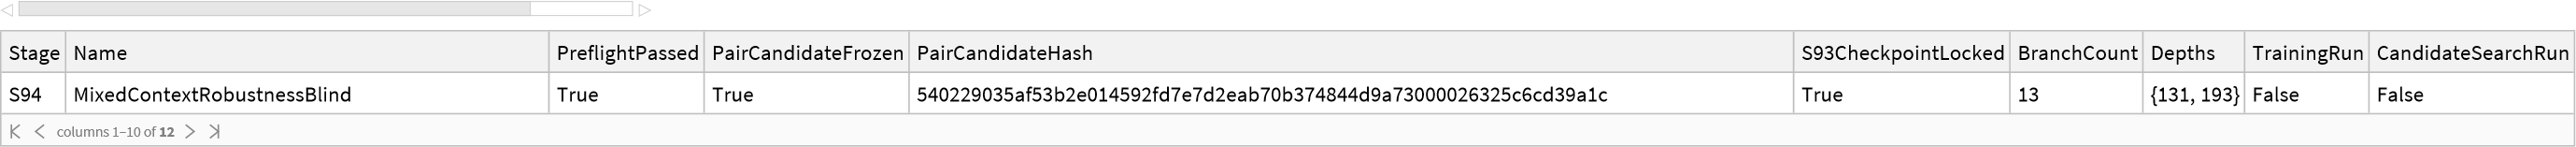

In [1095]:
expectedFrozenModelHash94=
"d6477c370436d09cf3e8cfc8530decd13ebf8bb79120362146ecb419f9d6a6c4";
expectedK33CandidateHash94=
"2eb674929cfe1710231a4f508d13b20fe0f98d84d2c594c6261f46f370066ae4";
expectedK33CandidateFileHash94=
"4a252b8977101d024b1b2feb00b4626ca28290c3982cdad199bc78ef7e0c98f1";
expectedBaseCandidateHash94=
"703e1365490a0123eac61745876dbcf29066abac4c753bb6ec1f61b790e222fe";
expectedBaseCandidateFileHash94=
"82616c6acde25ecd7bbbc51bc80d03771ec8653bf033167ac9ccd74d7da01d91";
expectedBaseRuntimeFileHash94=
"7d45fffdb3e33a0f0759ae9fa93c84429743cbe39fc7f02c38eeef11739740ee";
expectedPairCandidateHash94=
"540229035af53b2e014592fd7e7d2eab70b374844d9a73000026325c6cd39a1c";
expectedPairCandidateFileHash94=
"aecbe544a4af3a8ad0ba0494bb11312dd4a4b71f1a1c7ae42489a5300c7078ff";
expectedPairRuntimeFileHash94=
"74a926b8efccaddbd1dd07373ac35a93bc53e9fb08cc456ce1adb6a006d333c6";
expectedS92BCertificateFileHash94=
"85247775ef008a5ddf2378c54585d645dbf6b910d2b6085c1f8c29a98a9c2eb4";
expectedS92BCertificateResultHash94=
"0e3301be5d06af42d7e44ddb0e2b02e377fc378fcfefe98d928db875fc6c7373";
expectedS93CertificateFileHash94=
"d0c863119cf03e93e27e0db175163cd91ca4c980197a5fd1f6688f3ddc94c072";
expectedS93BlindResultHash94=
"335664ce1be5c14d2b8c7791960c6327f8a0a97067aca25857423be4e0b64d64";

k33CandidatePath94="E:/engine_wolf/TCCT_S86E_K33FrozenCandidate.wl";
baseRuntimePath94="E:/engine_wolf/TCCT_S87D_FrozenDecoderRuntime.wl";
baseCandidatePath94="E:/engine_wolf/TCCT_S87D_FrozenWorldMultisetDecoder.wxf";
pairRuntimePath94="E:/engine_wolf/TCCT_S92B_PairedContrastDecoderRuntime.wl";
pairCandidatePath94="E:/engine_wolf/TCCT_S92B_FrozenPairedContrastDecoder.wxf";
s92bCertificatePath94="E:/engine_wolf/TCCT_S92B_PairedContrastDecoderCertificate.json";
s93CertificatePath94="E:/engine_wolf/TCCT_S93_PairedCounterfactualBlindCertificate.json";
s94ResultCertificatePath="E:/engine_wolf/TCCT_S94_MixedContextRobustnessBlindCertificate.json";

ClearAll[FileSHA256Hex94];
FileSHA256Hex94[path_String]:=If[FileExistsQ[path],
IntegerString[FileHash[path,"SHA256"],16,64],Missing["FileMissing",path]];
requiredFiles94={k33CandidatePath94,baseRuntimePath94,baseCandidatePath94,
pairRuntimePath94,pairCandidatePath94,s92bCertificatePath94,s93CertificatePath94};
If[!And@@(FileExistsQ/@requiredFiles94),
Print["S94 aborted: one or more locked inputs are missing."];
Dataset[AssociationThread[requiredFiles94,FileExistsQ/@requiredFiles94]];Abort[]];
If[FileExistsQ[s94ResultCertificatePath],
Print["S94 aborted: a prior blind certificate exists. Preserve it."];Abort[]];

fileHashesBefore94=FileSHA256Hex94/@requiredFiles94;
Clear[frozenCandidate86E];Get[k33CandidatePath94];
k33HashLoaded94=Hash[Normal[frozenCandidate86E],"SHA256","HexString"];
Get[baseRuntimePath94];
baseDecoderLoaded94=Quiet@Check[TCCTLoadFrozenDecoderS87D[baseCandidatePath94],$Failed];
baseDecoderRaw94=If[AssociationQ[baseDecoderLoaded94],
KeyDrop[baseDecoderLoaded94,{"Classifier"}],$Failed];
Get[pairRuntimePath94];
pairDecoderLoaded94=Quiet@Check[
TCCTLoadFrozenPairDecoderS92B[pairCandidatePath94],$Failed];
pairDecoderRaw94=If[AssociationQ[pairDecoderLoaded94],
KeyDrop[pairDecoderLoaded94,{"Policy"}],$Failed];
s92bCertificate94=Quiet@Check[Import[s92bCertificatePath94,"RawJSON"],$Failed];
s93Certificate94=Quiet@Check[Import[s93CertificatePath94,"RawJSON"],$Failed];

ClearAll[CoreDefinitionBundle94,PairRuntimeDefinitionBundle94];
CoreDefinitionBundle94[]:=CoreDefinitionBundle86[];
PairRuntimeDefinitionBundle94[]:={DownValues[TCCTPairContrastVectorS92B],
DownValues[TCCTLoadFrozenPairDecoderS92B],
DownValues[TCCTPredictOrderedPairVectorsS92B],
DownValues[TCCTPredictOrderedPairWorldsS92B]};
modelHashBefore94=Hash[Normal[frozen75D],"SHA256","HexString"];
k33ObjectHashBefore94=Hash[Normal[frozenCandidate86E],"SHA256","HexString"];
baseDecoderObjectHashBefore94=Hash[Normal[baseDecoderRaw94],"SHA256","HexString"];
pairDecoderObjectHashBefore94=Hash[Normal[pairDecoderRaw94],"SHA256","HexString"];
coreHashBefore94=Hash[CoreDefinitionBundle94[],"SHA256","HexString"];
canonicalizerHashBefore94=Hash[{DownValues[FindPrivateDiamond79B],
DownValues[CanonicalizePrivateDiamonds79B],DownValues[CanonicalCase79B]},
"SHA256","HexString"];
interventionHashBefore94=Hash[{DownValues[LocalMediatorSources82],
DownValues[FullSemanticPatch82],DownValues[LocalMediatorPatch82],
DownValues[ReferenceAction82]},"SHA256","HexString"];
topologyPrimitiveHashBefore94=Hash[{DownValues[DiamondIn72],
DownValues[DoubleDiamondIn79],DownValues[HierarchicalDiamondIn80]},
"SHA256","HexString"];
baseRuntimeDefinitionHashBefore94=Hash[
TCCTFrozenFeatureDefinitionBundleS87D[],"SHA256","HexString"];
pairRuntimeDefinitionHashBefore94=Hash[
PairRuntimeDefinitionBundle94[],"SHA256","HexString"];

preflightPassed94=And[TrueQ[preflightPassed86],
SameQ[modelHashBefore94,expectedFrozenModelHash94],
AssociationQ[frozenCandidate86E],SameQ[k33HashLoaded94,expectedK33CandidateHash94],
SameQ[fileHashesBefore94[[1]],expectedK33CandidateFileHash94],
AssociationQ[baseDecoderLoaded94],
SameQ[baseDecoderLoaded94["CandidateHash"],expectedBaseCandidateHash94],
SameQ[fileHashesBefore94[[2]],expectedBaseRuntimeFileHash94],
SameQ[fileHashesBefore94[[3]],expectedBaseCandidateFileHash94],
AssociationQ[pairDecoderLoaded94],
SameQ[pairDecoderLoaded94["CandidateHash"],expectedPairCandidateHash94],
SameQ[fileHashesBefore94[[4]],expectedPairRuntimeFileHash94],
SameQ[fileHashesBefore94[[5]],expectedPairCandidateFileHash94],
SameQ[pairDecoderRaw94["ContrastPosition"],3],
SameQ[pairDecoderRaw94["Modulus"],33],
SameQ[pairDecoderRaw94["PolicyRules"],{
<|"Delta"->6,"Prediction"->"FirstStop"|>,
<|"Delta"->27,"Prediction"->"FirstContinue"|>}],
TrueQ[pairDecoderRaw94["FrozenBeforeS93"]],
AssociationQ[s92bCertificate94],
SameQ[fileHashesBefore94[[6]],expectedS92BCertificateFileHash94],
SameQ[s92bCertificate94["CertificateResultHash"],
expectedS92BCertificateResultHash94],
TrueQ[s92bCertificate94["FreezeValidityPassed"]],
AssociationQ[s93Certificate94],
SameQ[fileHashesBefore94[[7]],expectedS93CertificateFileHash94],
SameQ[s93Certificate94["BlindResultHash"],expectedS93BlindResultHash94],
SameQ[s93Certificate94["Outcome"],
"S93_BLIND_PAIRED_COUNTERFACTUAL_TRANSFER_PASS"],
TrueQ[s93Certificate94["TestValidityPassed"]],
TrueQ[s93Certificate94["BlindPerfect"]],
!FileExistsQ[s94ResultCertificatePath]];
preflight94=<|"Stage"->"S94","Name"->"MixedContextRobustnessBlind",
"PreflightPassed"->preflightPassed94,
"PairCandidateFrozen"->True,
"PairCandidateHash"->If[AssociationQ[pairDecoderLoaded94],
pairDecoderLoaded94["CandidateHash"],Missing[]],
"S93CheckpointLocked"->SameQ[fileHashesBefore94[[7]],
expectedS93CertificateFileHash94],
"BranchCount"->13,"Depths"->{131,193},
"TrainingRun"->False,"CandidateSearchRun"->False,
"RetuningApplied"->False,"S94ResultAlreadyPresent"->
FileExistsQ[s94ResultCertificatePath]|>;
If[!TrueQ[preflightPassed94],Print[Dataset[{preflight94}]];
Print["S94 aborted: frozen inputs or checkpoint locks failed."];Abort[]];
Dataset[{preflight94}]

Dataset[{<|Stage -> S94, Name -> MixedContextRobustnessBlind, 
 
>     Candidate -> S92B-FrozenPairedContrastDecoder, 
 
>     CandidateHash -> 540229035af53b2e014592fd7e7d2eab70b374844d9a73000026325c6cd39a1c, 
 
>     CandidateFileHash -> 
 
>      aecbe544a4af3a8ad0ba0494bb11312dd4a4b71f1a1c7ae42489a5300c7078ff, 
 
>     PairRuntimeFileHash -> 
 
>      74a926b8efccaddbd1dd07373ac35a93bc53e9fb08cc456ce1adb6a006d333c6, 
 
>     S93CheckpointFileHash -> 
 
>      d0c863119cf03e93e27e0db175163cd91ca4c980197a5fd1f6688f3ddc94c072, 
 
>     BranchCount -> 13, Depths -> {131, 193}, 
 
>     Topologies -> 
 
>      {DiamondAfterDoubleAfterHierarchical, HierarchicalAfterDiamondAfterDouble}, 
 
>     TopologySpecHash -> 
 
>      04daa5000cf3aa28d20ebdfeadefab5867ee51b853fd1cfd1f86fe1d82dc11e5, 
 
>     ExpectedScenarios -> 4, ExpectedPairs -> 52, ExpectedWorlds -> 104, 
 
>     ExpectedOrientedDecisions -> 104, 
 
>     ExternalGrammar -> IndependentThirteenBranchMixedContextT94, 
 
>     QueriedActionRegime -> ContinueVersusStop, 
 
>     NonQueryActionRegime -> AlternatingContinueStopWithTwoPhases, 
 
>     Pairing -> SameTopologyDepthAnswerNoiseContextBothInputOrders, 
 
>     CardinalityConstraint -> PairedCardinalityMustMatchButNeedNotBeOneOneZero, 
 
>     CandidateReads -> OnlyFrozenPosition3Modulo33PairContrast, 
 
>     SuccessCriterion -> ValidHarnessAndAll52PairsCorrectInBothOrders, 
 
>     CandidateFrozenBeforeProtocol -> True, TrainingRun -> False, 
 
>     CandidateSearchRun -> False, DecoderEditApplied -> False, 
 
>     RetuningApplied -> False, HistoricalBlindTestsRerun -> False, 
 
>     NoCaseEvaluatedBeforeProtocolHash -> True, 
 
>     ProtocolHash -> 4e0e41ef24649fde483e2e362e6bf83ffdc589da8ee3ae72f5e4caa6b5b91fd1, 
 
>     TestDefinitionHash -> 
 
>      5045ca99a3ba7f0133c917435e716c4cd7d78e3ba44c77729f63ff0e20e9c2ad|>}, 
 
>   TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[String], TypeSystem`AnyType, 31], 
 
>    1], <||>]
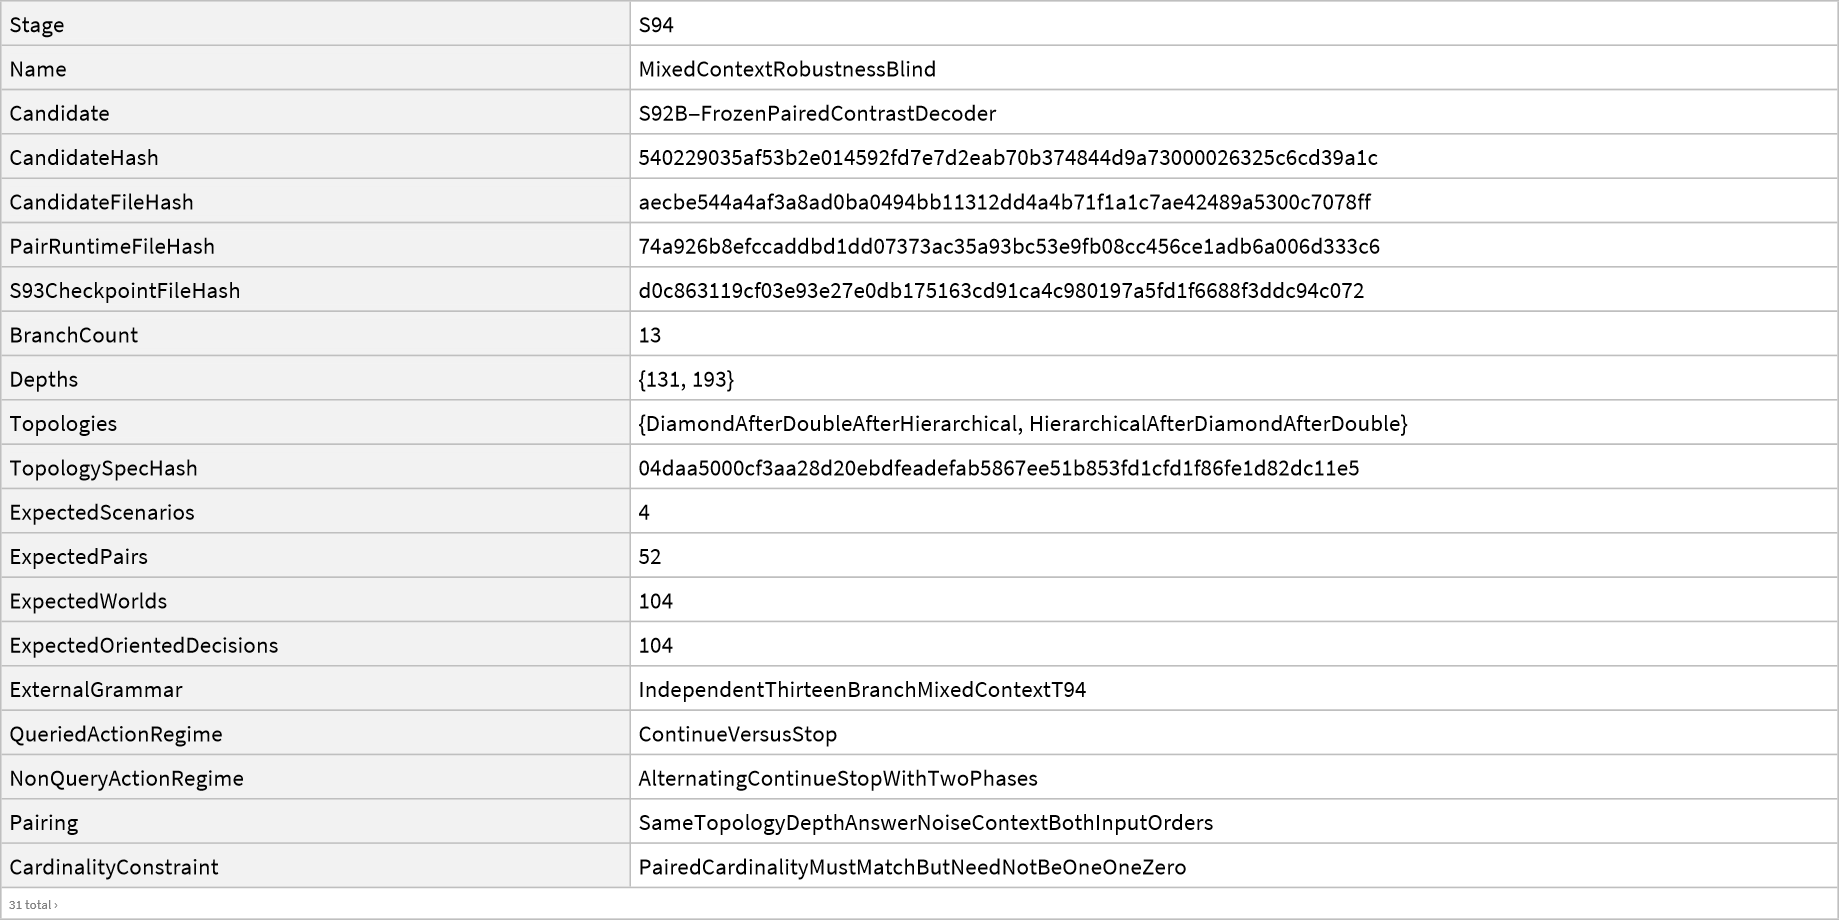

In [1153]:
ClearAll[T94,Case94,ReferenceAction94,NodeRole94,EncodePair94,
DiamondAfterDoubleAfterHierarchical94,
HierarchicalAfterDiamondAfterDouble94,TopologyTransform94,
NoisePhase94,ExpectedContractions94,PrepareWorld94,PrepareScenario94,
S94TestDefinitionBundle];

T94[depth_Integer,target_String,answer_Integer,seed_Integer,
branchCount_Integer,noisePhase_Integer]:=Module[
{bb,K,c,v,q,e,f={},ib,m,safe,u,dummy,r1,r2,wrong,main,perm,anc,
branchAction,i},
bb=1000000000 seed;K=bb+1;
c=Table[bb+100+i,{i,branchCount}];v=Table[bb+200+i,{i,branchCount}];
q=Table[bb+300+i,{i,branchCount}];
e=Flatten[Table[{DirectedEdge[K,c[[i]]],DirectedEdge[c[[i]],v[[i]]]},
{i,branchCount}],1];
Do[ib=bb+20000000 i;m=ib+1;safe=ib+2;u=ib+3;dummy=ib+4;
r1=ib+10;r2=ib+20;wrong=c[[1+Mod[i,branchCount]]];
main=Join[P59[q[[i]],r1,depth,ib+1000000],
P59[q[[i]],r2,depth,ib+2000000],{DirectedEdge[r1,m],DirectedEdge[r2,m]},
P59[q[[i]],safe,depth+1,ib+3000000]];
branchAction=If[i===answer,target,
If[EvenQ[i+noisePhase],"Continue","Stop"]];
perm=If[branchAction==="Continue",
{DirectedEdge[m,c[[i]]],DirectedEdge[safe,dummy],DirectedEdge[u,wrong]},
{DirectedEdge[m,wrong],DirectedEdge[safe,c[[i]]],DirectedEdge[u,dummy]}];
anc=Join[A59[m,i,bb+970000000+10000 i],
A59[c[[i]],i,bb+980000000+10000 i]];
e=Join[e,main,perm,anc];AppendTo[f,m],{i,branchCount}];
{{Union[e],q,K,v,c,f},answer}
];
Case94[depth_Integer,answer_Integer,target_String,noisePhase_Integer]:=
T94[depth,target,answer,94000000+100 depth+noisePhase,13,noisePhase];

ReferenceAction94[c_List]:=Module[{x=c[[1]],answer=c[[2]],branchCount,e,m,
safe,u,dummy,correct,wrong,continueEdges,stopEdges},
branchCount=Length[x[[6]]];e=x[[1]];m=x[[6,answer]];safe=m+1;u=m+2;
dummy=m+3;correct=x[[5,answer]];wrong=x[[5,1+Mod[answer,branchCount]]];
continueEdges={DirectedEdge[m,correct],DirectedEdge[safe,dummy],
DirectedEdge[u,wrong]};stopEdges={DirectedEdge[m,wrong],
DirectedEdge[safe,correct],DirectedEdge[u,dummy]};
Which[And@@(MemberQ[e,#]&/@continueEdges),"Continue",
And@@(MemberQ[e,#]&/@stopEdges),"Stop",True,"Undefined"]];

NodeRole94[originalNode_,case_List,answer_Integer]:=Module[
{x,branchCount,m,correct,wrong,dummy,querySources,queryBranch,role},
x=case[[1]];branchCount=Length[x[[6]]];m=x[[6,answer]];
correct=x[[5,answer]];wrong=x[[5,1+Mod[answer,branchCount]]];dummy=m+3;
querySources={m,m+1,m+2};queryBranch=Union[querySources,{correct,wrong,dummy}];
role=Which[SameQ[originalNode,m],"QueriedDecision",
MemberQ[querySources,originalNode],"QueriedMediatorSource",
SameQ[originalNode,correct],"QueriedCorrectDestination",
SameQ[originalNode,wrong],"QueriedWrongDestination",
SameQ[originalNode,dummy],"QueriedDummyDestination",
MemberQ[x[[6]],originalNode],"OtherDecision",
MemberQ[x[[5]],originalNode],"OtherAnswerDestination",True,"OtherReject"];
<|"Role"->role,"QueryBranchRelated"->MemberQ[queryBranch,originalNode]|>];

EncodePair94[pair_List]:=Module[{encoded},
encoded=First@EncodeRows75[{<|"Grammar"->"S94MixedContextObservation",
"Depth"->0,"Answer"->0,"Target"->"Unlabeled","StatePairs"->{pair}|>},
frozenCandidate86E["EncoderParams"],frozenCandidate86E["K"]];
First[encoded["Codes"]]];

DiamondAfterDoubleAfterHierarchical94[c_List]:=
DiamondIn72[DoubleDiamondIn79[HierarchicalDiamondIn80[c]]];
HierarchicalAfterDiamondAfterDouble94[c_List]:=
HierarchicalDiamondIn80[DiamondIn72[DoubleDiamondIn79[c]]];
TopologyTransform94[topology_String,c_List]:=Switch[topology,
"DiamondAfterDoubleAfterHierarchical",
DiamondAfterDoubleAfterHierarchical94[c],
"HierarchicalAfterDiamondAfterDouble",
HierarchicalAfterDiamondAfterDouble94[c],_,$Failed];
NoisePhase94[topology_String]:=Switch[topology,
"DiamondAfterDoubleAfterHierarchical",0,
"HierarchicalAfterDiamondAfterDouble",1,_,Missing["UnknownTopology"]];
ExpectedContractions94[topology_String,baseCase_List]:=Switch[topology,
"DiamondAfterDoubleAfterHierarchical",
6 DecisionIncomingEdgeCount79B[baseCase],
"HierarchicalAfterDiamondAfterDouble",
6 DecisionIncomingEdgeCount79B[baseCase],_,Missing["UnknownTopology"]];

PrepareWorld94[topology_String,depth_Integer,target_String,
answer_Integer]:=Module[{noisePhase,baseCase,topologyCase,canonicalization,
canonicalCase,expectedContractions,traceSeconds,trace,levels,pack,vertexList,
packedNodes,observations,originalNode,pair,roleInfo,featureVector,
singleWorldBaseline,nonQueryContinue,nonQueryStop},
noisePhase=NoisePhase94[topology];
baseCase=Case94[depth,answer,target,noisePhase];
topologyCase=TopologyTransform94[topology,baseCase];
canonicalization=CanonicalizePrivateDiamonds79B[topologyCase];
canonicalCase=canonicalization["Case"];
expectedContractions=ExpectedContractions94[topology,baseCase];
{traceSeconds,trace}=AbsoluteTiming[RejectTrace78[canonicalCase]];
levels=SigLevels61[canonicalCase,3];pack=Pack60[canonicalCase];
vertexList=pack[[12]];
packedNodes=If[Length[trace["Rejects"]]===0,{},
DeleteDuplicates[trace["Rejects"][[All,2]]]];
observations=Map[Function[packedNode,originalNode=vertexList[[packedNode]];
pair={Lookup[levels[[3]],packedNode],Lookup[levels[[4]],packedNode]};
roleInfo=NodeRole94[originalNode,canonicalCase,answer];
<|"Role"->roleInfo["Role"],
"QueryBranchRelated"->roleInfo["QueryBranchRelated"],
"Code"->EncodePair94[pair]|>],packedNodes];
featureVector=TCCTWorldVectorS87D[<|"Observations"->observations|>];
singleWorldBaseline=TCCTPredictWorldS87D[<|"Observations"->observations|>,
baseDecoderLoaded94];
nonQueryContinue=Count[DeleteCases[Range[13],answer],i_/;
EvenQ[i+noisePhase]];nonQueryStop=12-nonQueryContinue;
<|"Topology"->topology,"Depth"->depth,"NoisePhase"->noisePhase,
"GraphCondition"->"MixedContextQueried"<>target,"Answer"->answer,
"Target"->target,"ReferenceAction"->ReferenceAction94[canonicalCase],
"BranchCount"->13,"NonQueryContinueBranches"->nonQueryContinue,
"NonQueryStopBranches"->nonQueryStop,"FeatureVector"->featureVector,
"Cardinality"->featureVector[[{1,2,18}]],
"SingleWorldBaselinePrediction"->singleWorldBaseline,
"CanonicalCaseExactlyBase"->SameQ[canonicalCase,baseCase],
"Contractions"->canonicalization["Contractions"],
"ExpectedContractions"->expectedContractions,
"ContractionCountCorrect"->SameQ[canonicalization["Contractions"],
expectedContractions],"ProtectedNodesPreserved"->
canonicalization["ProtectedNodesPreserved"],
"TerminatedNaturally"->trace["TerminatedNaturally"],
"HitSafetyCap"->trace["HitSafetyCap"],"Rounds"->trace["Rounds"],
"TraceSeconds"->traceSeconds|>];

PrepareScenario94[topology_String,depth_Integer]:=Module[
{continueWorlds,stopWorlds,worldPairs},
continueWorlds=Table[PrepareWorld94[topology,depth,"Continue",answer],
{answer,Range[13]}];stopWorlds=Table[
PrepareWorld94[topology,depth,"Stop",answer],{answer,Range[13]}];
worldPairs=MapThread[Function[{continue,stop},Module[
{continueFirst,stopFirst},continueFirst=TCCTPredictOrderedPairVectorsS92B[
continue["FeatureVector"],stop["FeatureVector"],pairDecoderLoaded94];
stopFirst=TCCTPredictOrderedPairVectorsS92B[stop["FeatureVector"],
continue["FeatureVector"],pairDecoderLoaded94];
<|"Answer"->continue["Answer"],"ContinueFirstPrediction"->continueFirst,
"StopFirstPrediction"->stopFirst,
"ContinueFirstCorrect"->SameQ[continueFirst,"FirstContinue"],
"StopFirstCorrect"->SameQ[stopFirst,"FirstStop"],
"PairCorrect"->And[SameQ[continueFirst,"FirstContinue"],
SameQ[stopFirst,"FirstStop"]],
"CardinalityExactlyMatched"->SameQ[continue["Cardinality"],
stop["Cardinality"]],"FullFeatureVectorsDifferent"->
UnsameQ[continue["FeatureVector"],stop["FeatureVector"]],
"ReferenceRelationCorrect"->And[
SameQ[continue["ReferenceAction"],"Continue"],
SameQ[stop["ReferenceAction"],"Stop"]],
"ContinueWorld"->continue,"StopWorld"->stop|>]],
{continueWorlds,stopWorlds}];
<|"Topology"->topology,"Depth"->depth,"NoisePhase"->NoisePhase94[topology],
"AllCardinalitiesExactlyMatched"->And@@Lookup[worldPairs,
"CardinalityExactlyMatched"],"AllFullFeatureVectorsDifferent"->
And@@Lookup[worldPairs,"FullFeatureVectorsDifferent"],
"ReferenceRelationsCorrect"->And@@Lookup[worldPairs,
"ReferenceRelationCorrect"],"AllPairsCorrect"->And@@Lookup[worldPairs,
"PairCorrect"],"WorldPairs"->worldPairs,
"ContinueWorlds"->continueWorlds,"StopWorlds"->stopWorlds|>];

S94TestDefinitionBundle[]:={DownValues[T94],DownValues[Case94],
DownValues[ReferenceAction94],DownValues[NodeRole94],DownValues[EncodePair94],
DownValues[DiamondAfterDoubleAfterHierarchical94],
DownValues[HierarchicalAfterDiamondAfterDouble94],
DownValues[TopologyTransform94],DownValues[NoisePhase94],
DownValues[ExpectedContractions94],DownValues[PrepareWorld94],
DownValues[PrepareScenario94]};

blindBranchCount94=13;blindDepths94={131,193};
blindTopologies94={"DiamondAfterDoubleAfterHierarchical",
"HierarchicalAfterDiamondAfterDouble"};
topologySpec94=<|
"DiamondAfterDoubleAfterHierarchical"->
"DiamondIn72AfterDoubleDiamondIn79AfterHierarchicalDiamondIn80_Phase0",
"HierarchicalAfterDiamondAfterDouble"->
"HierarchicalDiamondIn80AfterDiamondIn72AfterDoubleDiamondIn79_Phase1"|>;
topologySpecHash94=Hash[Normal[topologySpec94],"SHA256","HexString"];
testDefinitionHashBefore94=Hash[S94TestDefinitionBundle[],"SHA256","HexString"];
noCasesBeforeProtocolHash94=And[!ValueQ[blindScenarios94],
!ValueQ[blindWorlds94],!ValueQ[blindPairs94]];
protocol94=<|"Stage"->"S94","Name"->"MixedContextRobustnessBlind",
"Candidate"->"S92B-FrozenPairedContrastDecoder",
"CandidateHash"->pairDecoderLoaded94["CandidateHash"],
"CandidateFileHash"->fileHashesBefore94[[5]],
"PairRuntimeFileHash"->fileHashesBefore94[[4]],
"S93CheckpointFileHash"->fileHashesBefore94[[7]],
"BranchCount"->13,"Depths"->blindDepths94,
"Topologies"->blindTopologies94,"TopologySpecHash"->topologySpecHash94,
"ExpectedScenarios"->4,"ExpectedPairs"->52,"ExpectedWorlds"->104,
"ExpectedOrientedDecisions"->104,
"ExternalGrammar"->"IndependentThirteenBranchMixedContextT94",
"QueriedActionRegime"->"ContinueVersusStop",
"NonQueryActionRegime"->"AlternatingContinueStopWithTwoPhases",
"Pairing"->"SameTopologyDepthAnswerNoiseContextBothInputOrders",
"CardinalityConstraint"->"PairedCardinalityMustMatchButNeedNotBeOneOneZero",
"CandidateReads"->"OnlyFrozenPosition3Modulo33PairContrast",
"SuccessCriterion"->"ValidHarnessAndAll52PairsCorrectInBothOrders",
"CandidateFrozenBeforeProtocol"->True,
"TrainingRun"->False,"CandidateSearchRun"->False,
"DecoderEditApplied"->False,"RetuningApplied"->False,
"HistoricalBlindTestsRerun"->False,
"NoCaseEvaluatedBeforeProtocolHash"->noCasesBeforeProtocolHash94|>;
protocolHash94=Hash[Normal[protocol94],"SHA256","HexString"];
Dataset[{Join[protocol94,<|"ProtocolHash"->protocolHash94,
"TestDefinitionHash"->testDefinitionHashBefore94|>]}]

Dataset[{<|Scenarios -> 4, Pairs -> 52, Worlds -> 104, OrientedDecisions -> 104, 
 
>     ContinueFirstCorrect -> 0, StopFirstCorrect -> 0, PairCorrect -> 0, 
 
>     UnknownPredictions -> 104, CardinalityPairsMatched -> 26, 
 
>     FullFeatureVectorPairsDifferent -> 52, ReferenceRelationsCorrect -> 52, 
 
>     ReferenceActionsCorrect -> 104, MixedContextWorlds -> 104, 
 
>     CanonicalCaseExactlyBase -> 104, ContractionCountCorrect -> 104, 
 
>     ProtectedNodesPreserved -> 104, ValidFeatureVectors -> 104, 
 
>     TerminatedNaturally -> 104, HitSafetyCap -> 0, ThirteenBranchWorlds -> 104, 
 
>     ScenarioCardinalityMatched -> 0, ScenarioFullVectorsDifferent -> 4, 
 
>     ScenarioReferenceRelationsCorrect -> 4, ScenarioPerfect -> 0, 
 
>     SingleWorldBaselineCorrect -> 78, 
 
>     CardinalityDistribution -> <|{1, 1, 0} -> 78, {2, 2, 1} -> 26|>, 
 
>     TotalTraceSeconds -> 749.396|>}, 
 
>   TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[String], TypeSystem`AnyType, 27], 
 
>    1], <||>]
Dataset[{<|Topology -> DiamondAfterDoubleAfterHierarchical, Pairs -> 26, 
 
>     PairCorrect -> 0, Unknown -> 52|>, 
 
>    <|Topology -> HierarchicalAfterDiamondAfterDouble, Pairs -> 26, PairCorrect -> 0, 
 
>     Unknown -> 52|>}, TypeSystem`Vector[TypeSystem`Struct[{Topology, Pairs, 
 
>      PairCorrect, Unknown}, {TypeSystem`Atom[String], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer]}], 2], <||>]
Dataset[{<|Depth -> 131, Pairs -> 26, PairCorrect -> 0|>, 
 
>    <|Depth -> 193, Pairs -> 26, PairCorrect -> 0|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Depth, Pairs, PairCorrect}, 
 
>     {TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer]}], 2]
 
>    , <||>]
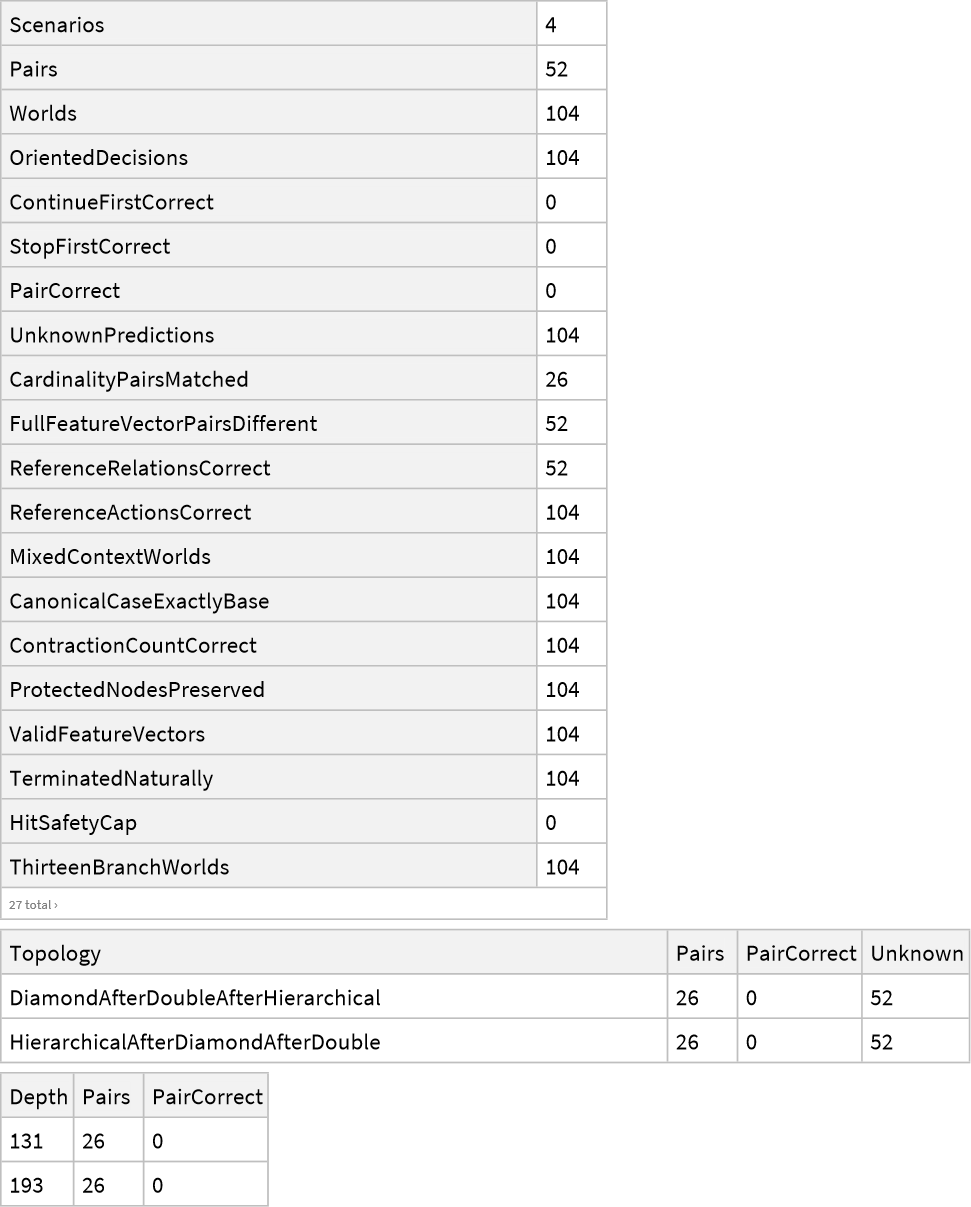

In [1180]:
blindScenarios94=Flatten[Table[PrepareScenario94[topology,depth],
{topology,blindTopologies94},{depth,blindDepths94}],1];
continueWorlds94=Flatten[Lookup[blindScenarios94,"ContinueWorlds"],1];
stopWorlds94=Flatten[Lookup[blindScenarios94,"StopWorlds"],1];
blindWorlds94=Join[continueWorlds94,stopWorlds94];
blindPairs94=Flatten[Lookup[blindScenarios94,"WorldPairs"],1];
summary94=<|"Scenarios"->Length[blindScenarios94],
"Pairs"->Length[blindPairs94],"Worlds"->Length[blindWorlds94],
"OrientedDecisions"->2 Length[blindPairs94],
"ContinueFirstCorrect"->Count[blindPairs94,p_/;
TrueQ[p["ContinueFirstCorrect"]]],"StopFirstCorrect"->Count[blindPairs94,p_/;
TrueQ[p["StopFirstCorrect"]]],"PairCorrect"->Count[blindPairs94,p_/;
TrueQ[p["PairCorrect"]]],"UnknownPredictions"->Total[
Count[Lookup[blindPairs94,#],"Unknown"]&/@
{"ContinueFirstPrediction","StopFirstPrediction"}],
"CardinalityPairsMatched"->Count[blindPairs94,p_/;
TrueQ[p["CardinalityExactlyMatched"]]],
"FullFeatureVectorPairsDifferent"->Count[blindPairs94,p_/;
TrueQ[p["FullFeatureVectorsDifferent"]]],
"ReferenceRelationsCorrect"->Count[blindPairs94,p_/;
TrueQ[p["ReferenceRelationCorrect"]]],
"ReferenceActionsCorrect"->Count[blindWorlds94,w_/;
SameQ[w["ReferenceAction"],w["Target"]]],
"MixedContextWorlds"->Count[blindWorlds94,w_/;And[
w["NonQueryContinueBranches"]>0,w["NonQueryStopBranches"]>0]],
"CanonicalCaseExactlyBase"->Count[blindWorlds94,w_/;
TrueQ[w["CanonicalCaseExactlyBase"]]],
"ContractionCountCorrect"->Count[blindWorlds94,w_/;
TrueQ[w["ContractionCountCorrect"]]],
"ProtectedNodesPreserved"->Count[blindWorlds94,w_/;
TrueQ[w["ProtectedNodesPreserved"]]],
"ValidFeatureVectors"->Count[blindWorlds94,w_/;
VectorQ[w["FeatureVector"],IntegerQ]&&Length[w["FeatureVector"]]===27],
"TerminatedNaturally"->Count[blindWorlds94,w_/;
TrueQ[w["TerminatedNaturally"]]],"HitSafetyCap"->Count[blindWorlds94,w_/;
TrueQ[w["HitSafetyCap"]]],"ThirteenBranchWorlds"->Count[blindWorlds94,w_/;
SameQ[w["BranchCount"],13]],"ScenarioCardinalityMatched"->
Count[blindScenarios94,s_/;TrueQ[s["AllCardinalitiesExactlyMatched"]]],
"ScenarioFullVectorsDifferent"->Count[blindScenarios94,s_/;
TrueQ[s["AllFullFeatureVectorsDifferent"]]],
"ScenarioReferenceRelationsCorrect"->Count[blindScenarios94,s_/;
TrueQ[s["ReferenceRelationsCorrect"]]],"ScenarioPerfect"->
Count[blindScenarios94,s_/;TrueQ[s["AllPairsCorrect"]]],
"SingleWorldBaselineCorrect"->Count[blindWorlds94,w_/;
SameQ[w["SingleWorldBaselinePrediction"],w["Target"]]],
"CardinalityDistribution"->Counts[Lookup[blindWorlds94,"Cardinality"]],
"TotalTraceSeconds"->Total@Lookup[blindWorlds94,"TraceSeconds"]|>;
byTopology94=Map[Function[topology,Module[{pairs},pairs=Select[blindPairs94,
SameQ[#1["ContinueWorld"]["Topology"],topology]&];
<|"Topology"->topology,"Pairs"->Length[pairs],
"PairCorrect"->Count[pairs,p_/;TrueQ[p["PairCorrect"]]],
"Unknown"->Total[Count[Lookup[pairs,#],"Unknown"]&/@
{"ContinueFirstPrediction","StopFirstPrediction"}]|>]],blindTopologies94];
byDepth94=Map[Function[depth,Module[{pairs},pairs=Select[blindPairs94,
SameQ[#1["ContinueWorld"]["Depth"],depth]&];
<|"Depth"->depth,"Pairs"->Length[pairs],
"PairCorrect"->Count[pairs,p_/;TrueQ[p["PairCorrect"]]]|>]],blindDepths94];
Column[{Dataset[{summary94}],Dataset[byTopology94],Dataset[byDepth94]}]

Dataset[{<|Stage -> S94, Name -> MixedContextRobustnessBlind, 
 
>     CandidateHash -> 540229035af53b2e014592fd7e7d2eab70b374844d9a73000026325c6cd39a1c, 
 
>     CandidateFileHash -> 
 
>      aecbe544a4af3a8ad0ba0494bb11312dd4a4b71f1a1c7ae42489a5300c7078ff, 
 
>     PairRuntimeFileHash -> 
 
>      74a926b8efccaddbd1dd07373ac35a93bc53e9fb08cc456ce1adb6a006d333c6, 
 
>     S93CheckpointFileHash -> 
 
>      d0c863119cf03e93e27e0db175163cd91ca4c980197a5fd1f6688f3ddc94c072, 
 
>     ProtocolHash -> 4e0e41ef24649fde483e2e362e6bf83ffdc589da8ee3ae72f5e4caa6b5b91fd1, 
 
>     TestDefinitionHash -> 
 
>      5045ca99a3ba7f0133c917435e716c4cd7d78e3ba44c77729f63ff0e20e9c2ad, 
 
>     BranchCount -> 13, Depths -> {131, 193}, 
 
>     Topologies -> 
 
>      {DiamondAfterDoubleAfterHierarchical, HierarchicalAfterDiamondAfterDouble}, 
 
>     Scenarios -> 4, Pairs -> 52, Worlds -> 104, OrientedDecisions -> 104, 
 
>     ContinueFirstCorrect -> 0, StopFirstCorrect -> 0, PairCorrect -> 0, 
 
>     OrientedAccuracy -> 0., UnknownPredictions -> 104, CardinalityPairsMatched -> 26, 
 
>     CardinalityDistribution -> <|{1, 1, 0} -> 78, {2, 2, 1} -> 26|>, 
 
>     FullFeatureVectorPairsDifferent -> 52, MixedContextWorlds -> 104, 
 
>     SingleWorldBaselineCorrect -> 78, TestValidityPassed -> False, 
 
>     BlindPerfect -> False, OriginalFrozenModelChanged -> False, 
 
>     BaseFrozenS87DDecoderChanged -> False, FrozenPairDecoderChanged -> False, 
 
>     CoreChanged -> False, CanonicalizerChanged -> False, 
 
>     InterventionCoreChanged -> False, TopologyPrimitivesChanged -> False, 
 
>     BaseFeatureRuntimeChanged -> False, PairRuntimeChanged -> False, 
 
>     TestDefinitionChangedDuringRun -> False, ProtocolChangedDuringRun -> False, 
 
>     DeduplicationMechanismChanged -> False, UndirectedFreezeMechanismChanged -> False, 
 
>     CandidateFrozenBeforeS94 -> True, BlindProtocolHashedBeforeCases -> True, 
 
>     TrainingRun -> False, CandidateSearchRun -> False, DecoderEditApplied -> False, 
 
>     RetuningApplied -> False, HistoricalBlindTestsRerun -> False, 
 
>     MayClaimBlindMixedContextRobustness -> False, 
 
>     MayClaimGeneralCounterfactualReasoning -> False, MayClaimCausalDiscovery -> False, 
 
>     TotalTraceSeconds -> 749.396, 
 
>     BlindResultHash -> 
 
>      157b0ed8c3b106fc6f7aa31fae21382b0f238dccaeb48e1b3f2b2f381732925e, 
 
>     Outcome -> S94_INVALID_BLIND_TEST_DO_NOT_INTERPRET, 
 
>     SuggestedNextStage -> S94R_REPAIR_HARNESS_WITHOUT_MODEL_CHANGE|>}, 
 
>   TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[String], TypeSystem`AnyType, 54], 
 
>    1], <||>]
Dataset[{<|Topology -> DiamondAfterDoubleAfterHierarchical, Pairs -> 26, 
 
>     PairCorrect -> 0, Unknown -> 52|>, 
 
>    <|Topology -> HierarchicalAfterDiamondAfterDouble, Pairs -> 26, PairCorrect -> 0, 
 
>     Unknown -> 52|>}, TypeSystem`Vector[TypeSystem`Struct[{Topology, Pairs, 
 
>      PairCorrect, Unknown}, {TypeSystem`Atom[String], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer]}], 2], <||>]
Dataset[{<|Depth -> 131, Pairs -> 26, PairCorrect -> 0|>, 
 
>    <|Depth -> 193, Pairs -> 26, PairCorrect -> 0|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Depth, Pairs, PairCorrect}, 
 
>     {TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer]}], 2]
 
>    , <||>]
Dataset[{<|CertificateExported -> False, 
 
>     CertificatePath -> 
 
>      E:/engine_wolf/TCCT_S94_MixedContextRobustnessBlindCertificate.json, 
 
>     CertificateFileHash -> Missing[]|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{CertificateExported, CertificatePath, 
 
>      CertificateFileHash}, {TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[String], TypeSystem`UnknownType}], 1], <||>]
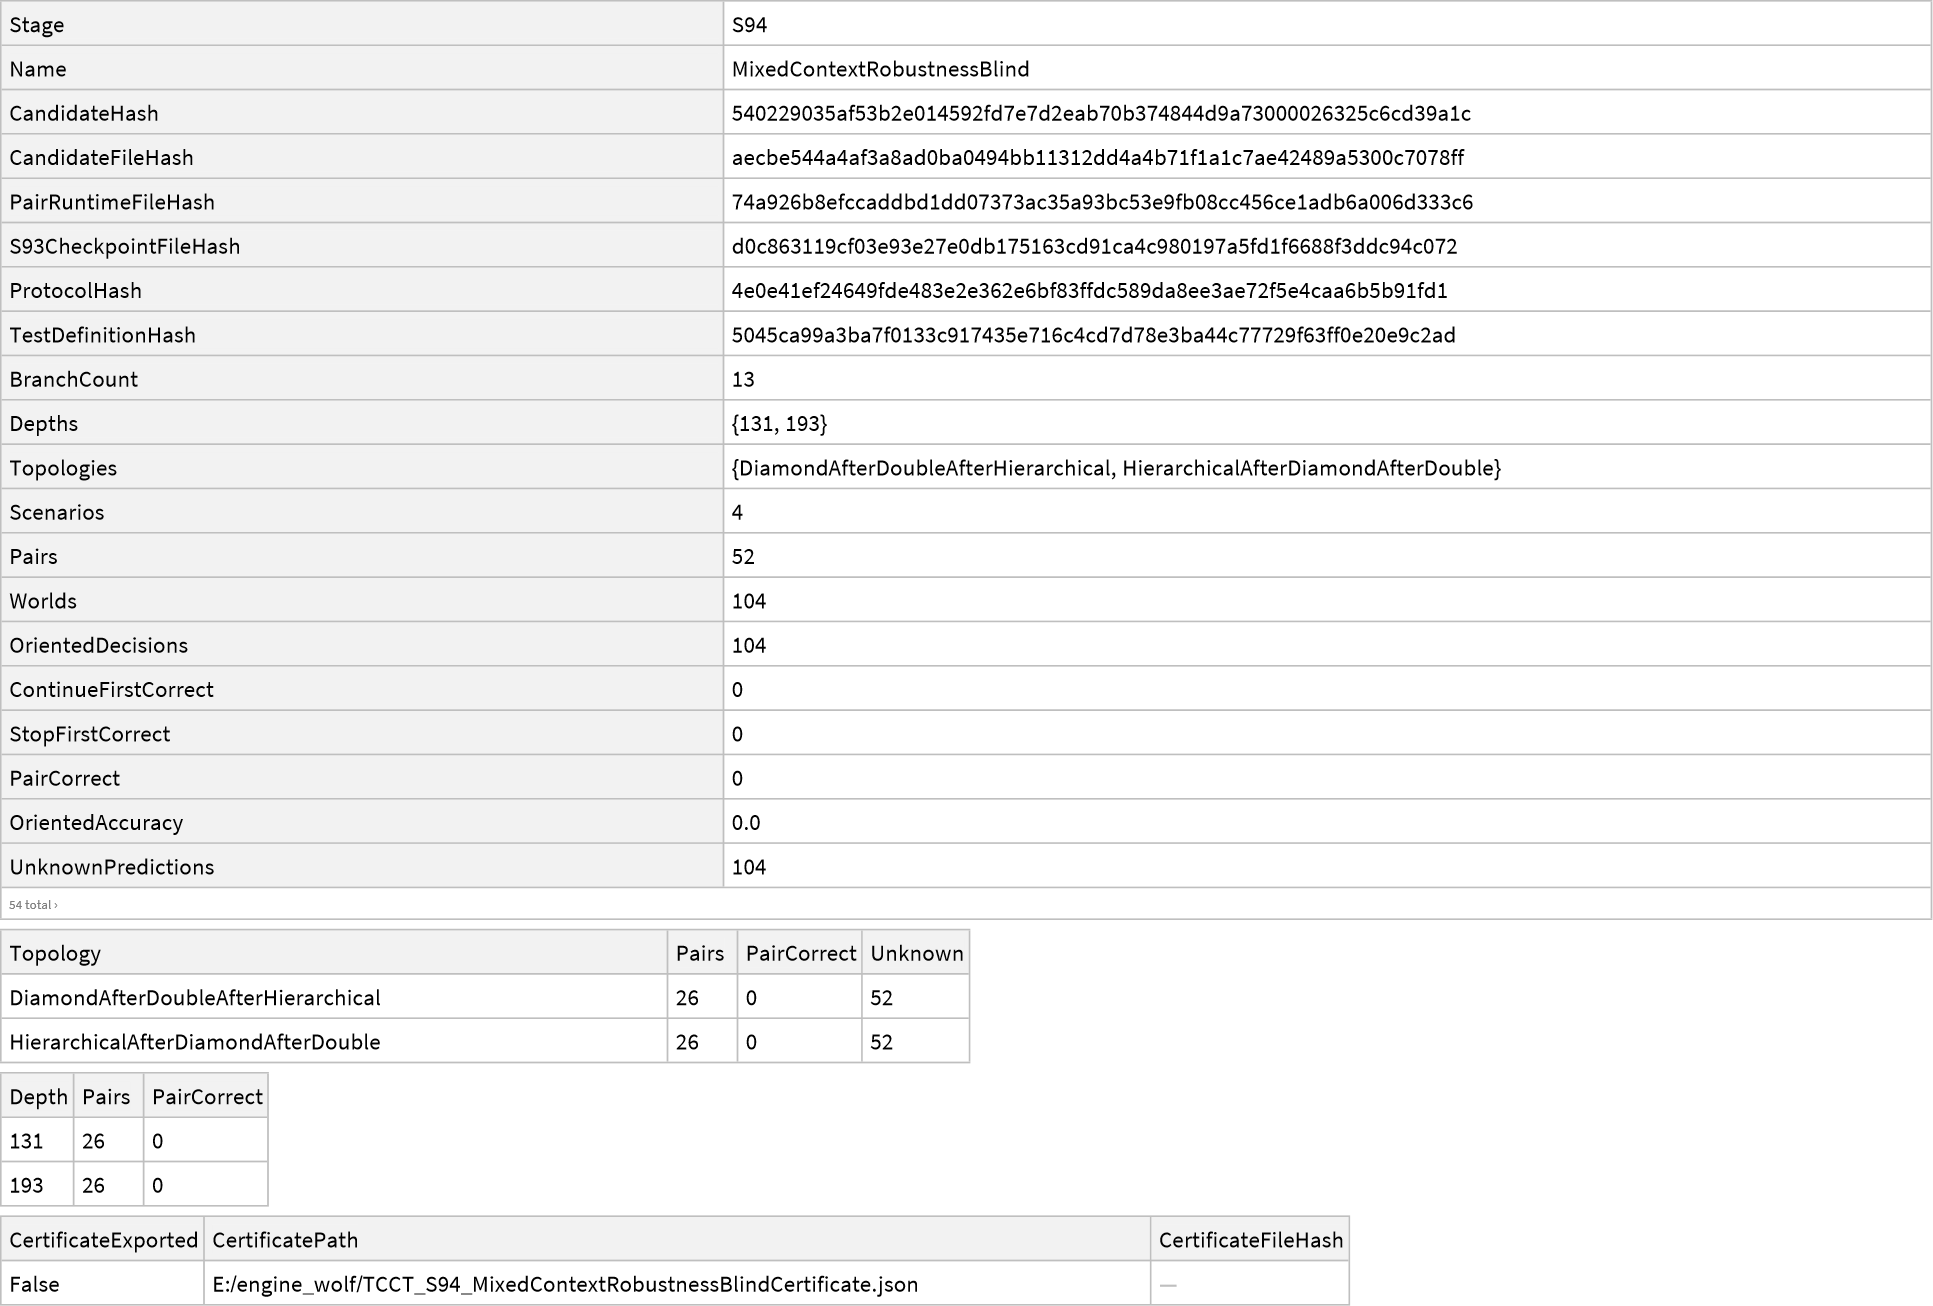

In [1189]:
modelHashAfter94=Hash[Normal[frozen75D],"SHA256","HexString"];
k33ObjectHashAfter94=Hash[Normal[frozenCandidate86E],"SHA256","HexString"];
baseDecoderObjectHashAfter94=Hash[Normal[KeyDrop[baseDecoderLoaded94,
{"Classifier"}]],"SHA256","HexString"];
pairDecoderObjectHashAfter94=Hash[Normal[KeyDrop[pairDecoderLoaded94,
{"Policy"}]],"SHA256","HexString"];
coreHashAfter94=Hash[CoreDefinitionBundle94[],"SHA256","HexString"];
canonicalizerHashAfter94=Hash[{DownValues[FindPrivateDiamond79B],
DownValues[CanonicalizePrivateDiamonds79B],DownValues[CanonicalCase79B]},
"SHA256","HexString"];
interventionHashAfter94=Hash[{DownValues[LocalMediatorSources82],
DownValues[FullSemanticPatch82],DownValues[LocalMediatorPatch82],
DownValues[ReferenceAction82]},"SHA256","HexString"];
topologyPrimitiveHashAfter94=Hash[{DownValues[DiamondIn72],
DownValues[DoubleDiamondIn79],DownValues[HierarchicalDiamondIn80]},
"SHA256","HexString"];
baseRuntimeDefinitionHashAfter94=Hash[
TCCTFrozenFeatureDefinitionBundleS87D[],"SHA256","HexString"];
pairRuntimeDefinitionHashAfter94=Hash[PairRuntimeDefinitionBundle94[],
"SHA256","HexString"];
testDefinitionHashAfter94=Hash[S94TestDefinitionBundle[],"SHA256","HexString"];
protocolHashAfter94=Hash[Normal[protocol94],"SHA256","HexString"];
fileHashesAfter94=FileSHA256Hex94/@requiredFiles94;
integrityPassed94=And[SameQ[modelHashBefore94,modelHashAfter94],
SameQ[k33ObjectHashBefore94,k33ObjectHashAfter94],
SameQ[baseDecoderObjectHashBefore94,baseDecoderObjectHashAfter94],
SameQ[pairDecoderObjectHashBefore94,pairDecoderObjectHashAfter94],
SameQ[coreHashBefore94,coreHashAfter94],
SameQ[canonicalizerHashBefore94,canonicalizerHashAfter94],
SameQ[interventionHashBefore94,interventionHashAfter94],
SameQ[topologyPrimitiveHashBefore94,topologyPrimitiveHashAfter94],
SameQ[baseRuntimeDefinitionHashBefore94,baseRuntimeDefinitionHashAfter94],
SameQ[pairRuntimeDefinitionHashBefore94,pairRuntimeDefinitionHashAfter94],
SameQ[testDefinitionHashBefore94,testDefinitionHashAfter94],
SameQ[protocolHash94,protocolHashAfter94],
SameQ[fileHashesBefore94,fileHashesAfter94]];
testValidityPassed94=And[TrueQ[integrityPassed94],
SameQ[summary94["Scenarios"],4],SameQ[summary94["Pairs"],52],
SameQ[summary94["Worlds"],104],SameQ[summary94["OrientedDecisions"],104],
SameQ[summary94["CardinalityPairsMatched"],52],
SameQ[summary94["FullFeatureVectorPairsDifferent"],52],
SameQ[summary94["ReferenceRelationsCorrect"],52],
SameQ[summary94["ReferenceActionsCorrect"],104],
SameQ[summary94["MixedContextWorlds"],104],
SameQ[summary94["CanonicalCaseExactlyBase"],104],
SameQ[summary94["ContractionCountCorrect"],104],
SameQ[summary94["ProtectedNodesPreserved"],104],
SameQ[summary94["ValidFeatureVectors"],104],
SameQ[summary94["TerminatedNaturally"],104],
SameQ[summary94["HitSafetyCap"],0],
SameQ[summary94["ThirteenBranchWorlds"],104],
SameQ[summary94["ScenarioCardinalityMatched"],4],
SameQ[summary94["ScenarioFullVectorsDifferent"],4],
SameQ[summary94["ScenarioReferenceRelationsCorrect"],4]];
blindPerfect94=And[TrueQ[testValidityPassed94],
SameQ[summary94["UnknownPredictions"],0],
SameQ[summary94["ContinueFirstCorrect"],52],
SameQ[summary94["StopFirstCorrect"],52],
SameQ[summary94["PairCorrect"],52],SameQ[summary94["ScenarioPerfect"],4]];
orientedAccuracy94=N[(summary94["ContinueFirstCorrect"]+
summary94["StopFirstCorrect"])/104];
resultPayload94=<|"Stage"->"S94","Name"->"MixedContextRobustnessBlind",
"CandidateHash"->pairDecoderLoaded94["CandidateHash"],
"CandidateFileHash"->fileHashesAfter94[[5]],
"PairRuntimeFileHash"->fileHashesAfter94[[4]],
"S93CheckpointFileHash"->fileHashesAfter94[[7]],
"ProtocolHash"->protocolHashAfter94,
"TestDefinitionHash"->testDefinitionHashAfter94,
"BranchCount"->13,"Depths"->blindDepths94,
"Topologies"->blindTopologies94,"Scenarios"->summary94["Scenarios"],
"Pairs"->summary94["Pairs"],"Worlds"->summary94["Worlds"],
"OrientedDecisions"->summary94["OrientedDecisions"],
"ContinueFirstCorrect"->summary94["ContinueFirstCorrect"],
"StopFirstCorrect"->summary94["StopFirstCorrect"],
"PairCorrect"->summary94["PairCorrect"],
"OrientedAccuracy"->orientedAccuracy94,
"UnknownPredictions"->summary94["UnknownPredictions"],
"CardinalityPairsMatched"->summary94["CardinalityPairsMatched"],
"CardinalityDistribution"->summary94["CardinalityDistribution"],
"FullFeatureVectorPairsDifferent"->
summary94["FullFeatureVectorPairsDifferent"],
"MixedContextWorlds"->summary94["MixedContextWorlds"],
"SingleWorldBaselineCorrect"->summary94["SingleWorldBaselineCorrect"],
"TestValidityPassed"->testValidityPassed94,"BlindPerfect"->blindPerfect94,
"OriginalFrozenModelChanged"->!SameQ[modelHashBefore94,modelHashAfter94],
"BaseFrozenS87DDecoderChanged"->!SameQ[baseDecoderObjectHashBefore94,
baseDecoderObjectHashAfter94],"FrozenPairDecoderChanged"->
!SameQ[pairDecoderObjectHashBefore94,pairDecoderObjectHashAfter94],
"CoreChanged"->!SameQ[coreHashBefore94,coreHashAfter94],
"CanonicalizerChanged"->!SameQ[canonicalizerHashBefore94,
canonicalizerHashAfter94],"InterventionCoreChanged"->
!SameQ[interventionHashBefore94,interventionHashAfter94],
"TopologyPrimitivesChanged"->!SameQ[topologyPrimitiveHashBefore94,
topologyPrimitiveHashAfter94],"BaseFeatureRuntimeChanged"->
!SameQ[baseRuntimeDefinitionHashBefore94,baseRuntimeDefinitionHashAfter94],
"PairRuntimeChanged"->!SameQ[pairRuntimeDefinitionHashBefore94,
pairRuntimeDefinitionHashAfter94],"TestDefinitionChangedDuringRun"->
!SameQ[testDefinitionHashBefore94,testDefinitionHashAfter94],
"ProtocolChangedDuringRun"->!SameQ[protocolHash94,protocolHashAfter94],
"DeduplicationMechanismChanged"->!SameQ[coreHashBefore94,coreHashAfter94],
"UndirectedFreezeMechanismChanged"->!SameQ[coreHashBefore94,coreHashAfter94]|>;
blindResultHash94=Hash[Normal[resultPayload94],"SHA256","HexString"];
cert94=Join[resultPayload94,<|"CandidateFrozenBeforeS94"->True,
"BlindProtocolHashedBeforeCases"->True,"TrainingRun"->False,
"CandidateSearchRun"->False,"DecoderEditApplied"->False,
"RetuningApplied"->False,"HistoricalBlindTestsRerun"->False,
"MayClaimBlindMixedContextRobustness"->blindPerfect94,
"MayClaimGeneralCounterfactualReasoning"->False,
"MayClaimCausalDiscovery"->False,
"TotalTraceSeconds"->summary94["TotalTraceSeconds"],
"BlindResultHash"->blindResultHash94,
"Outcome"->Which[!TrueQ[testValidityPassed94],
"S94_INVALID_BLIND_TEST_DO_NOT_INTERPRET",TrueQ[blindPerfect94],
"S94_BLIND_MIXED_CONTEXT_ROBUSTNESS_PASS",True,
"S94_VALID_BLIND_FAILURE_DO_NOT_RETUNE"],
"SuggestedNextStage"->Which[!TrueQ[testValidityPassed94],
"S94R_REPAIR_HARNESS_WITHOUT_MODEL_CHANGE",TrueQ[blindPerfect94],
"S95_PARTIAL_OBSERVATION_AND_PAIR_MISMATCH_STRESS",True,
"S94A_FAILURE_AUDIT_WITHOUT_RETUNING"]|>];
certificateExportResult94=Quiet@Check[
Export[s94ResultCertificatePath,cert94,"RawJSON"],$Failed];
certificateExported94=StringQ[certificateExportResult94]&&
FileExistsQ[s94ResultCertificatePath];
Column[{Dataset[{cert94}],Dataset[byTopology94],Dataset[byDepth94],
Dataset[{<|"CertificateExported"->certificateExported94,
"CertificatePath"->s94ResultCertificatePath,
"CertificateFileHash"->If[certificateExported94,
FileSHA256Hex94[s94ResultCertificatePath],Missing[]]|>}]}]